# run after gaussian fit script

In [14]:
# ----- Masks -----
egfp_hi = adata.obs["EGFP_Seq1_hi"].values
td_hi   = adata.obs["tdTomato_Seq2_hi"].values
dual_hi = adata.obs["EGFP_tdTomato_dual_hi"].values

# Single positives
egfp_only = egfp_hi & ~td_hi
td_only   = td_hi   & ~egfp_hi

# ----- Extract obs annotations -----
cols = ["seurat_labels", "scanvi_labels"]

egfp_only_labels = adata.obs.loc[egfp_only, cols]
td_only_labels   = adata.obs.loc[td_only, cols]
dual_labels      = adata.obs.loc[dual_hi, cols]

# Optional: all positive (EGFP or tdTomato)
any_pos_labels   = adata.obs.loc[egfp_hi | td_hi, cols]

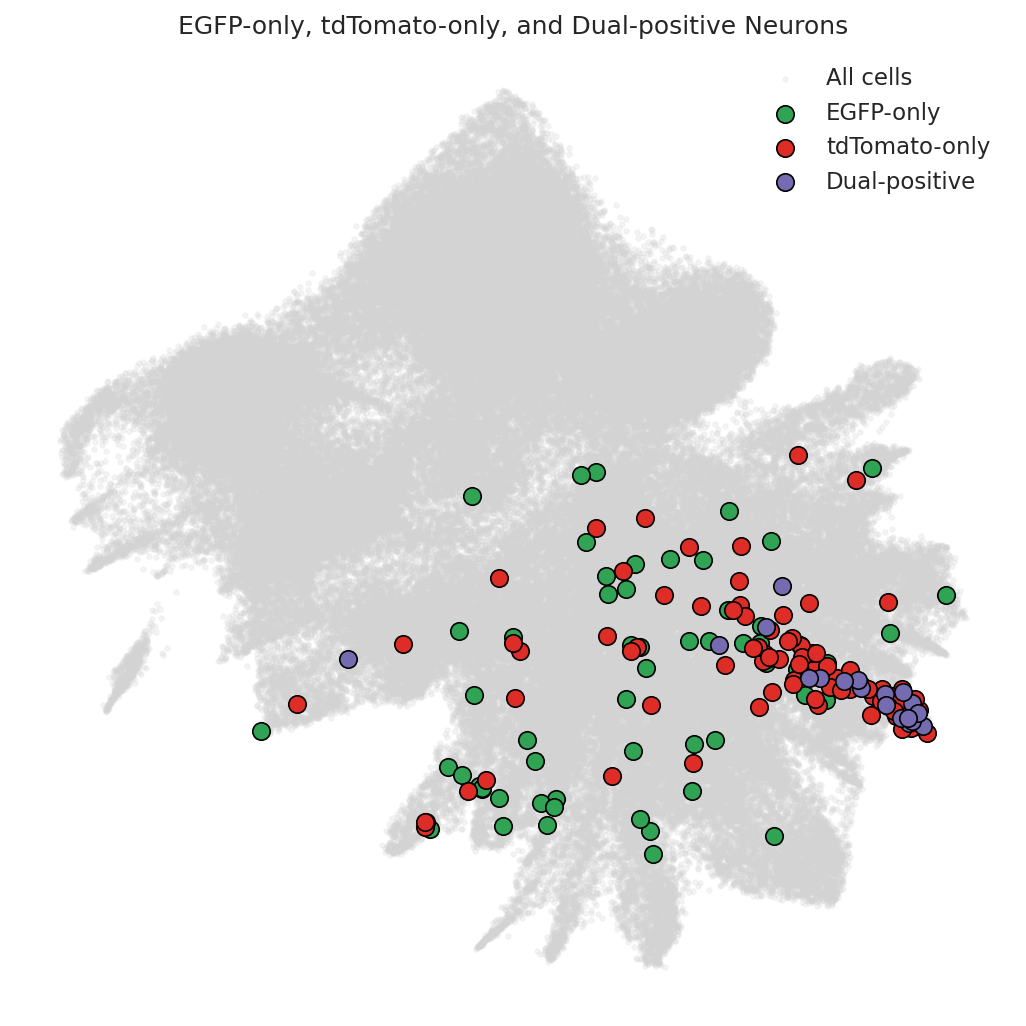

In [23]:
# ----------------------------------------
# 1. Masks already created
# ----------------------------------------
egfp_hi = adata.obs["EGFP_Seq1_hi"].values
td_hi   = adata.obs["tdTomato_Seq2_hi"].values
dual_hi = adata.obs["EGFP_tdTomato_dual_hi"].values

egfp_only = egfp_hi & ~td_hi
td_only   = td_hi   & ~egfp_hi

# ----------------------------------------
# 2. Get UMAP coordinates and indices
# ----------------------------------------
umap = adata.obsm["X_umap"]

egfp_idx = np.where(egfp_only)[0]
td_idx   = np.where(td_only)[0]
dual_idx = np.where(dual_hi)[0]

# ----------------------------------------
# 3. Plot
# ----------------------------------------
plt.figure(figsize=(7, 7), dpi=150)

# Background
plt.scatter(
    umap[:, 0], umap[:, 1],
    s=5, c="lightgray", alpha=0.20,
    label="All cells"
)

# EGFP-only (green)
plt.scatter(
    umap[egfp_idx, 0], umap[egfp_idx, 1],
    s=70, c="#31a354",
    edgecolors="black", linewidths=0.8,
    label="EGFP-only"
)

# tdTomato-only (red)
plt.scatter(
    umap[td_idx, 0], umap[td_idx, 1],
    s=70, c="#de2d26",
    edgecolors="black", linewidths=0.8,
    label="tdTomato-only"
)

# Dual positive (purple)
plt.scatter(
    umap[dual_idx, 0], umap[dual_idx, 1],
    s=70, c="#756bb1",
    edgecolors="black", linewidths=0.8,
    label="Dual-positive"
)

plt.title("EGFP-only, tdTomato-only, and Dual-positive Neurons")
plt.xticks([]); plt.yticks([])
sns.despine(left=True, bottom=True)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

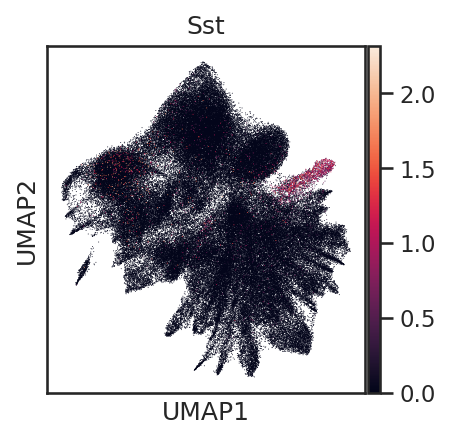

In [24]:
sc.pl.umap(adata, color = 'Sst')

In [15]:
summary = pd.DataFrame({
    "EGFP_only": [egfp_only.sum()],
    "tdTomato_only": [td_only.sum()],
    "dual_high": [dual_hi.sum()],
    "any_positive": [(egfp_hi | td_hi).sum()]
})
summary

,EGFP_only,tdTomato_only,dual_high,any_positive
0,58,93,19,170


# Visualization

In [79]:
def plot_bar_from_labels(
    data,
    label_col,
    title,
    figsize=(6,4),
    horizontal=False,
    color="steelblue"
):
    counts = data[label_col].value_counts()

    # Use seaborn style that *keeps* ticks
    sns.set_style("ticks")

    fig, ax = plt.subplots(figsize=figsize)

    # ---- Plot ----
    if horizontal:
        sns.barplot(
            y=counts.index,
            x=counts.values,
            color=color,
            edgecolor="black",
            ax=ax
        )
        ax.set_xlabel("Count", fontsize=10)
        ax.set_ylabel(label_col, fontsize=10)

        # integer ticks
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    else:
        sns.barplot(
            x=counts.index,
            y=counts.values,
            color=color,
            edgecolor="black",
            ax=ax
        )
        ax.set_ylabel("Count", fontsize=10)
        ax.set_xlabel(label_col, fontsize=10)
        plt.xticks(rotation=45, ha="right", fontsize=9)
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # ---- Make tick marks visible and nice ----
    ax.tick_params(
        axis="both",
        which="both",
        length=4,
        width=1,
        direction="out",
        labelsize=9
    )

    # Keep only bottom & left spines (clean aesthetic)
    sns.despine(ax=ax)

    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

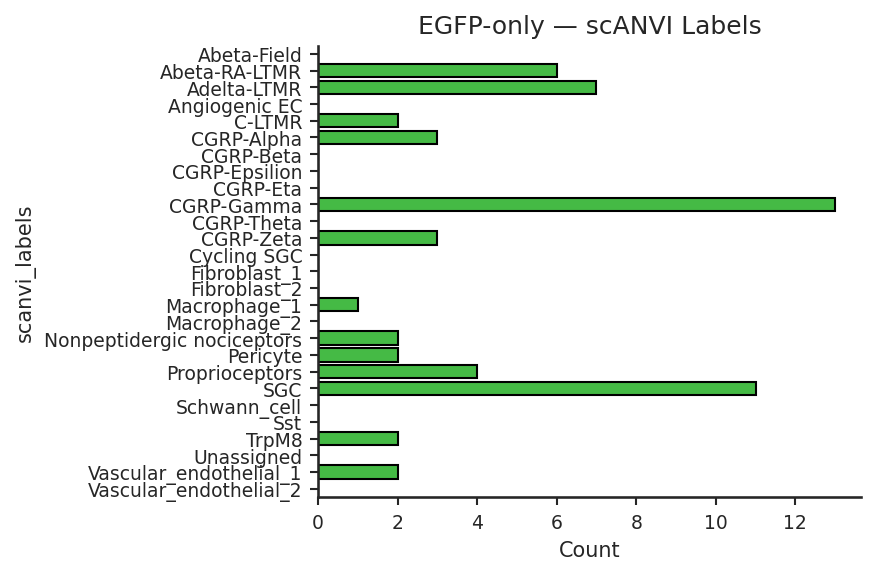

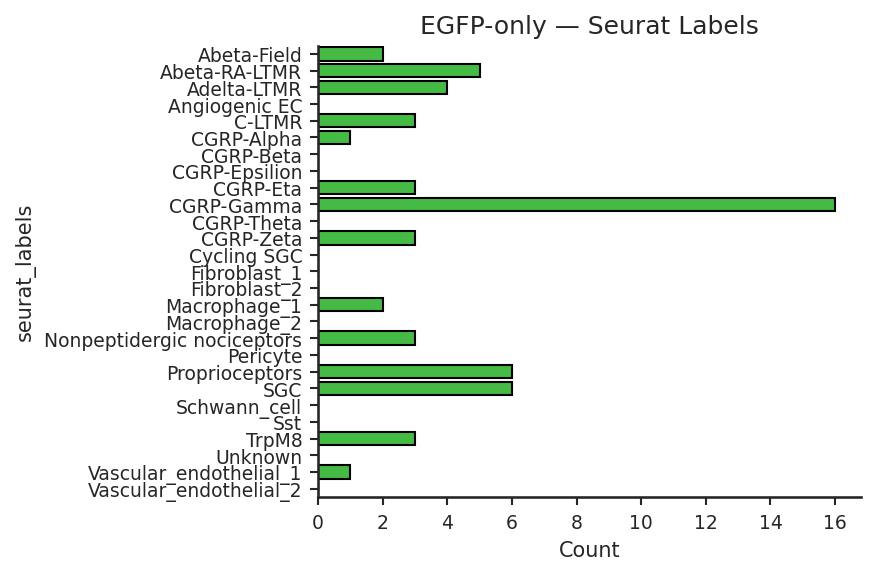

In [80]:
# EGFP-only — scANVI
plot_bar_from_labels(
    adata.obs[egfp_only],
    label_col="scanvi_labels",
    title="EGFP-only — scANVI Labels",
    horizontal=True,
    color="limegreen"
)

# EGFP-only — Seurat
plot_bar_from_labels(
    adata.obs[egfp_only],
    label_col="seurat_labels",
    title="EGFP-only — Seurat Labels",
    horizontal=True,
    color="limegreen"
)

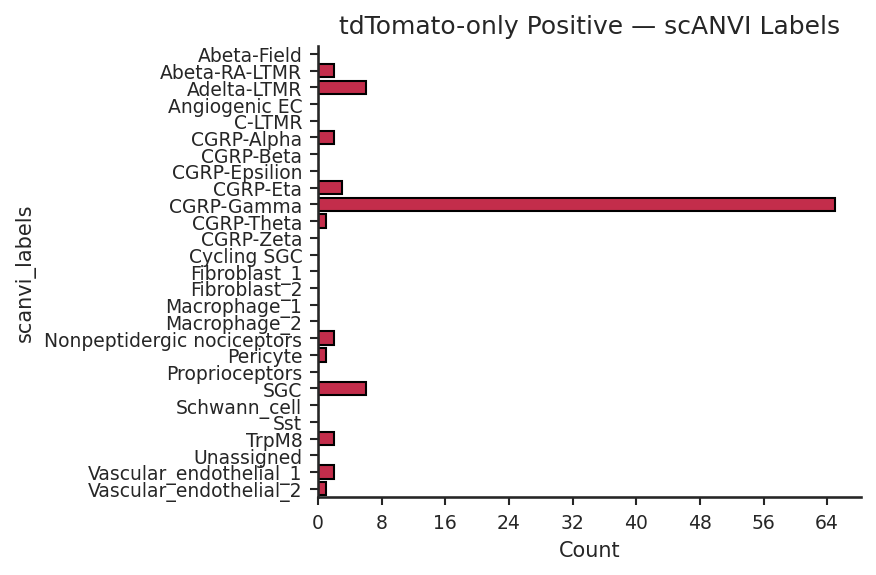

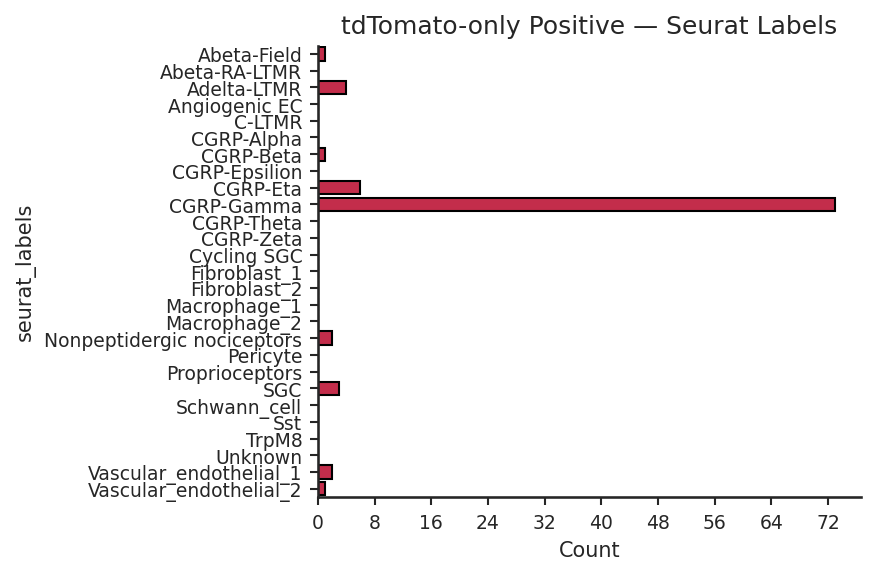

In [81]:
# tdTomato-only: scANVI labels (bright red)
plot_bar_from_labels(
    adata.obs[td_only],
    "scanvi_labels",
    "tdTomato-only Positive — scANVI Labels",
    horizontal=True,
    color="crimson"
)

# tdTomato-only: Seurat labels (bright red)
plot_bar_from_labels(
    adata.obs[td_only],
    "seurat_labels",
    "tdTomato-only Positive — Seurat Labels",
    horizontal=True,
    color="crimson"
)

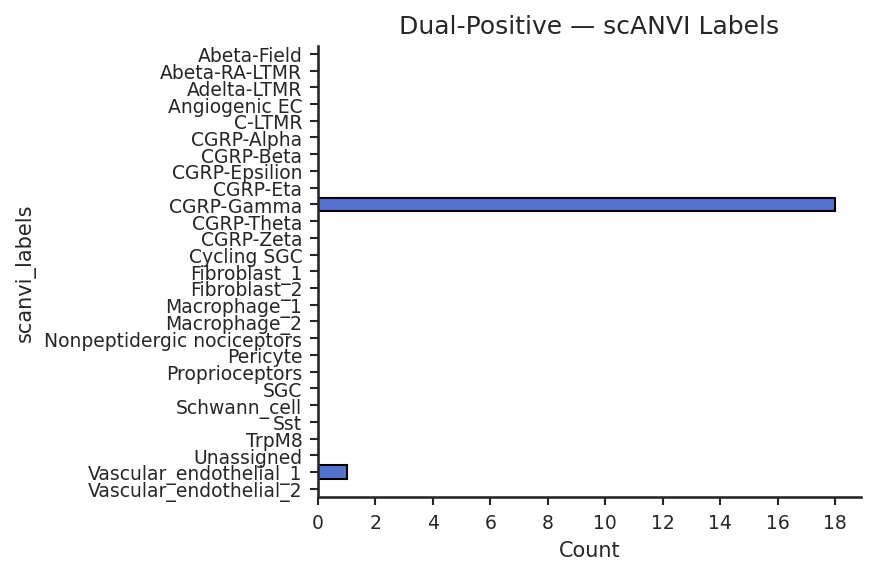

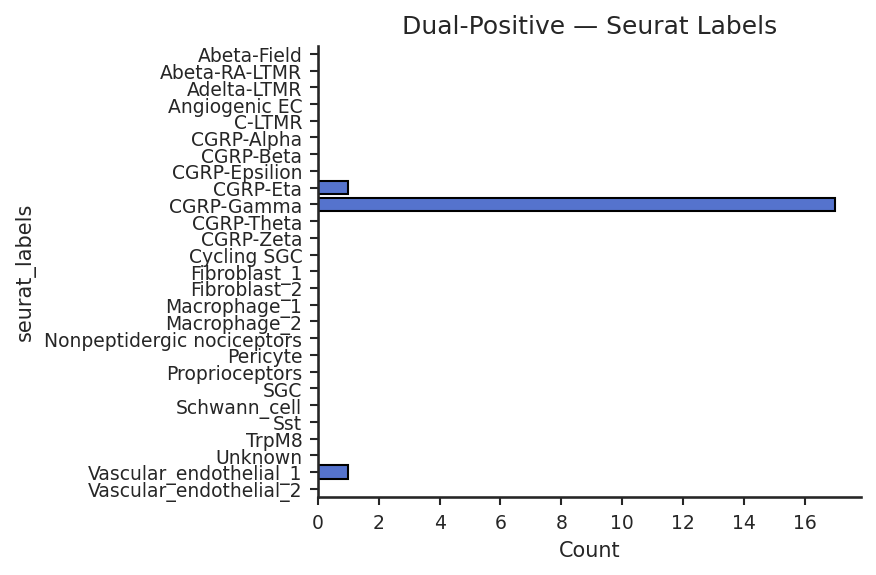

In [82]:
# Dual-positive: scANVI labels (royalblue)
plot_bar_from_labels(
    adata.obs[dual_hi],
    "scanvi_labels",
    "Dual-Positive — scANVI Labels",
    horizontal=True,
    color="royalblue"
)

# Dual-positive: Seurat labels (royalblue)
plot_bar_from_labels(
    adata.obs[dual_hi],
    "seurat_labels",
    "Dual-Positive — Seurat Labels",
    horizontal=True,
    color="royalblue"
)

# Subset to neurons

In [21]:
adata.obs.scanvi_labels.value_counts()

scanvi_labels
Schwann_cell                  29178
SGC                           25707
Macrophage_2                  17655
Vascular_endothelial_1         7810
Nonpeptidergic nociceptors     7500
CGRP-Gamma                     7412
Fibroblast_2                   6881
Macrophage_1                   4452
Vascular_endothelial_2         4383
Fibroblast_1                   4360
CGRP-Eta                       3909
Abeta-RA-LTMR                  3733
CGRP-Alpha                     3635
C-LTMR                         2878
TrpM8                          2798
CGRP-Zeta                      2292
Pericyte                       2146
Sst                            1734
Adelta-LTMR                    1642
CGRP-Theta                     1575
CGRP-Epsilion                  1479
Abeta-Field                    1365
Unassigned                      769
Proprioceptors                  689
Cycling SGC                     128
Angiogenic EC                   110
CGRP-Beta                        56
Name: count, d

In [83]:
# Define neuron class labels
neuron_labels = {
    "Nonpeptidergic nociceptors",
    "CGRP-Gamma",
    "CGRP-Eta",
    "Abeta-RA-LTMR",
    "CGRP-Alpha",
    "C-LTMR",
    "TrpM8",
    "CGRP-Zeta",
    "Sst",
    "Adelta-LTMR",
    "CGRP-Theta",
    "CGRP-Epsilion",
    "Abeta-Field",
    "Proprioceptors",
    "CGRP-Beta"
}

# Create a new column with “Neuron” or “Non-neuron”
adata.obs["class_seurat"] = np.where(
    adata.obs["seurat_labels"].isin(neuron_labels),
    "Neuron",
    "Non-neuron"
)

In [84]:
adata.obs.class_seurat.value_counts()

class_seurat
Non-neuron    97055
Neuron        49221
Name: count, dtype: int64

In [117]:
def plot_seurat_for_subset(adata_subset, title, color="steelblue", horizontal=True):
    """
    adata_subset : an AnnData object (e.g., neuron-only)
    """
    # Extract seurat_labels from the subset as a DataFrame
    df = adata_subset.obs[["seurat_labels"]].copy()

    # Remove missing values just in case
    df = df.dropna(subset=["seurat_labels"])

    plot_bar_from_labels(
        df,
        "seurat_labels",
        title,
        horizontal=horizontal,
        color=color
    )

In [118]:
neuron_adata = adata[adata.obs["class_seurat"] == "Neuron"].copy()

# Remove unused categories from all categorical columns
for col in neuron_adata.obs.select_dtypes(include="category").columns:
    neuron_adata.obs[col] = neuron_adata.obs[col].cat.remove_unused_categories()
    
neuron_adata.obs.class_seurat.value_counts()

class_seurat
Neuron    49221
Name: count, dtype: int64

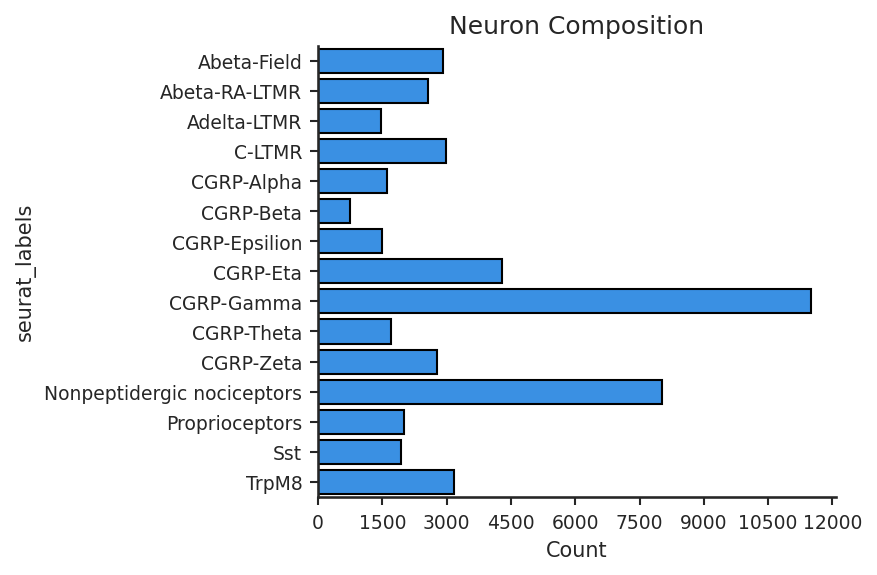

In [120]:
plot_seurat_for_subset(
    neuron_adata,
    title="Neuron Composition",
    color="dodgerblue",
    horizontal=True
)

In [141]:
import matplotlib.pyplot as plt

# ---------------------------------------------
# 1) Restrict to neurons only
# ---------------------------------------------
neuron_adata = adata[adata.obs["class_seurat"] == "Neuron"].copy()

egfp_hi = neuron_adata.obs["EGFP_Seq1_hi"]
td_hi   = neuron_adata.obs["tdTomato_Seq2_hi"]

# ---------------------------------------------
# 2) Compute true tdTomato-only vs dual inside neurons
# ---------------------------------------------
dual_hi_neuron   = egfp_hi & td_hi           # EGFP+ AND tdTomato+
td_only_neuron   = td_hi & ~egfp_hi          # tdTomato+ AND NOT EGFP+

# ---------------------------------------------
# 3) Denominator = all tdTomato+ neurons
# ---------------------------------------------
total_td_neuron = (dual_hi_neuron | td_only_neuron).sum()

print("Total tdTomato+ Neurons:", total_td_neuron)
print("Dual-positive Neurons:", dual_hi_neuron.sum())
print("tdTomato-only Neurons:", td_only_neuron.sum())

Total tdTomato+ Neurons: 105
Dual-positive Neurons: 18
tdTomato-only Neurons: 87


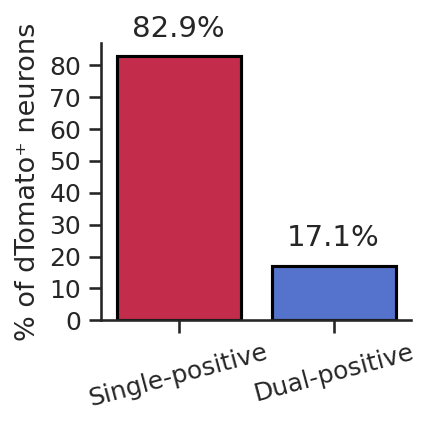

In [160]:
counts = {
    "Single-positive": td_only_neuron.sum(),
    "Dual-positive": dual_hi_neuron.sum(),
}

labels = list(counts.keys())
values = list(counts.values())

# Compute percentages
total = sum(values)
percentages = [(v / total) * 100 for v in values]

plt.figure(figsize=(3, 3))      
sns.set_style("ticks")

ax = sns.barplot(
    x=labels,
    y=percentages,
    palette=["crimson", "royalblue"],
    edgecolor="black",
    linewidth=1.5,
)

# ---- Add percent labels above bars ----
for i, pct in enumerate(percentages):
    ax.text(
        i,
        pct + max(percentages) * 0.05, 
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=14,
    )

# ---- Axis formatting ----
ax.set_ylabel("% of dTomato⁺ neurons", fontsize=13)
ax.set_xlabel("")

# rotate labels a little so they don’t collide
plt.xticks(rotation=15, ha="center", fontsize=12)

ax.tick_params(axis="y", labelsize=12)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

sns.despine()
plt.tight_layout()
plt.show()